In [1]:
import numpy as np
import pandas as pd

In [2]:
# parsing the csv toa panda dataframe
df = pd.read_csv("Zomato Dataset.csv")

In [3]:
df.head

<bound method NDFrame.head of            ID Delivery_person_ID  Delivery_person_Age  \
0      0xcdcd      DEHRES17DEL01                 36.0   
1      0xd987      KOCRES16DEL01                 21.0   
2      0x2784     PUNERES13DEL03                 23.0   
3      0xc8b6     LUDHRES15DEL02                 34.0   
4      0xdb64      KNPRES14DEL02                 24.0   
...       ...                ...                  ...   
45579  0x7c09      JAPRES04DEL01                 30.0   
45580  0xd641      AGRRES16DEL01                 21.0   
45581  0x4f8d     CHENRES08DEL03                 30.0   
45582  0x5eee    COIMBRES11DEL01                 20.0   
45583  0x5fb2   RANCHIRES09DEL02                 23.0   

       Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  \
0                          4.2            30.327968             78.046106   
1                          4.7            10.003064             76.307589   
2                          4.7            18.562450   

In [4]:
# data structure 
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

(45584, 20)

In [5]:
# finding all the fake coordinates (0,0) and near it
print(((df['Restaurant_latitude'].abs() < 1) & (df['Restaurant_longitude'].abs() < 1)).sum())
print(((df['Delivery_location_latitude'].abs() < 1) & (df['Delivery_location_longitude'].abs() < 1)).sum())
# 3640 poor geo coordinates data

# data summary
print(df['Time_taken (min)'].describe())

# missing value count per column,
df.isnull().sum().sort_values(ascending=False)

3640
3640
count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64


Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Weather_conditions              616
Road_traffic_density            601
Festival                        228
ID                                0
Delivery_person_ID                0
Restaurant_latitude               0
Restaurant_longitude              0
Time_Order_picked                 0
Order_Date                        0
Delivery_location_latitude        0
Delivery_location_longitude       0
Type_of_vehicle                   0
Type_of_order                     0
Vehicle_condition                 0
Time_taken (min)                  0
dtype: int64

In [6]:
# removing the rows with poor data and saving the new filtered data 
df_clean = df[~((df['Restaurant_latitude'].abs() < 1) & (df['Restaurant_longitude'].abs() < 1))].copy()
print(df_clean.shape)

(41944, 20)


In [7]:
# distance is a important feature, so we find the distance between two coordinates by using the haversine formula

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df_clean['distance_km'] = haversine(
    df_clean['Restaurant_latitude'], df_clean['Restaurant_longitude'],
    df_clean['Delivery_location_latitude'], df_clean['Delivery_location_longitude']
)

print(df_clean['distance_km'].describe())

count    41944.000000
mean       107.080686
std       1146.240729
min          1.465067
25%          4.658001
50%          9.220368
75%         13.760880
max      19692.674606
Name: distance_km, dtype: float64


In [8]:
# finding distances which dont feel appealing (food delivery for a distance more than 50 or 100 kms ?)
print((df_clean['distance_km'] > 30).sum())
print((df_clean['distance_km'] > 50).sum())
print((df_clean['distance_km'] > 100).sum())

# what does the distribution look like, ignoring the extreme tail?
print(df_clean['distance_km'].quantile([0.90, 0.95, 0.99]))

431
431
431
0.90      19.396618
0.95      20.177520
0.99    2231.896982
Name: distance_km, dtype: float64


In [9]:
# removing the useless data (mostly outliers)
df_clean = df_clean[df_clean['distance_km'] <= 30].copy()
print(df_clean.shape)
print(df_clean['distance_km'].describe())

(41513, 21)
count    41513.000000
mean         9.719824
std          5.602505
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64


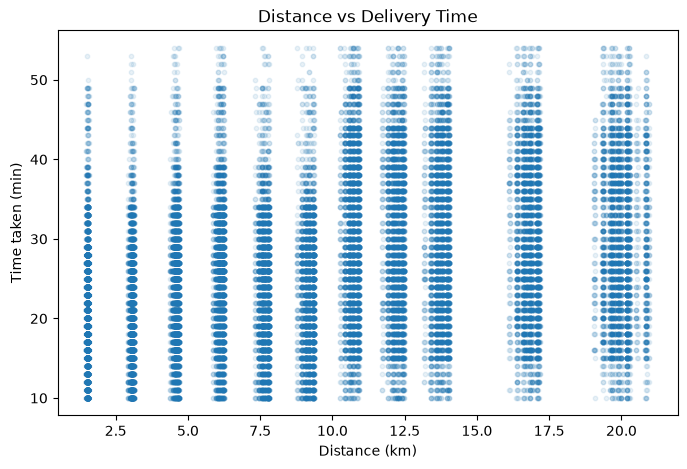

In [10]:
# now we use matplot lib to plot the cleaned dataset, and interpret the visual observcations
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_clean['distance_km'], df_clean['Time_taken (min)'], alpha=0.1, s=10)
plt.xlabel('Distance (km)')
plt.ylabel('Time taken (min)')
plt.title('Distance vs Delivery Time')
plt.show()

In [11]:
# the plot shows that strips of distances, rather than being continuous, we can see discrete bars
# also as normal person would expect that greater distances would take less time while the shorter ones would be quick to deliver
# moreover, we could even see that some deliveries despite having small distances took a big span of time, alternatively, longer distances 
# have even taken short time period 
# 
# Takeaway : maybe time isnt the only feature thats affecting the delivery times  

In [12]:
# finding the coorelation coefficient, relationship between 2 variables (-1 to 1)
print(df_clean['distance_km'].corr(df_clean['Time_taken (min)']))

0.3210619560247977


In [13]:
# the value of covariance gave an 0.3 which is almost an weak to mid corelating value, thus
# we conclude that distance is probably not the dominating feature 

# now lets shift focus to another factor, say traffic jams which can affect a short distance to being late, or empty roads leading to quicker deliveries

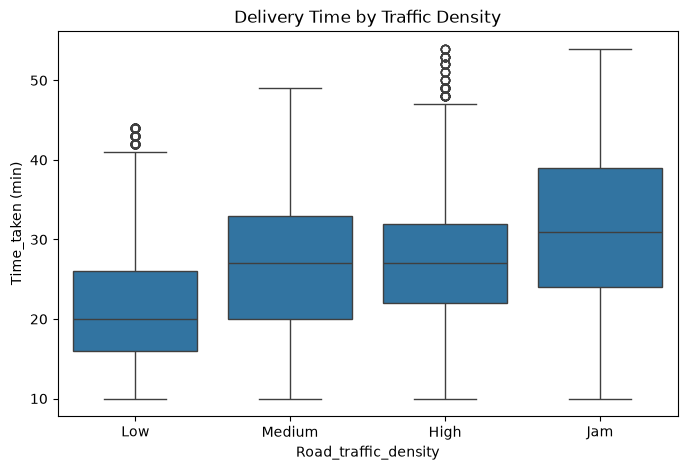

In [14]:
# traffic jam is categorical and time is continuous so we use boxplot
import seaborn as sns
order = ['Low', 'Medium', 'High', 'Jam']
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Road_traffic_density', y='Time_taken (min)', order=order)
plt.title('Delivery Time by Traffic Density')
plt.show()

In [15]:
# traffic density shows a real, visible separation between groups, a much clearer visualization to see how traffic is affecting delivery times

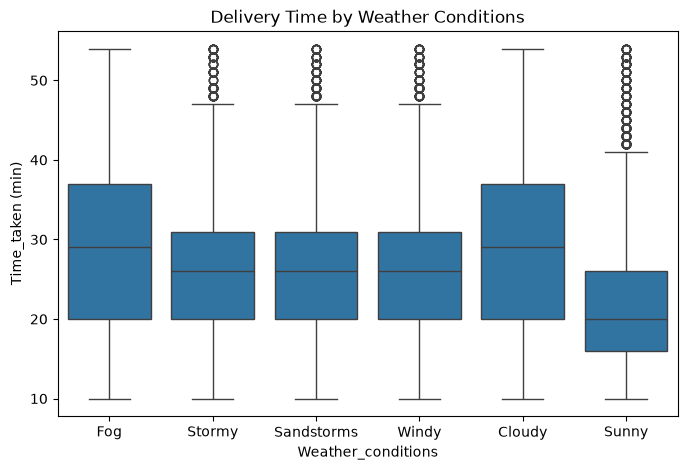

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Weather_conditions', y='Time_taken (min)')
plt.title('Delivery Time by Weather Conditions')
plt.show()

In [17]:
# as expected the deliveries are faster on sunny days, almost similar on the days, while the maximum on cloudy and foggy

In [18]:
# now checking the plot between mulitple deliveries and delivery times

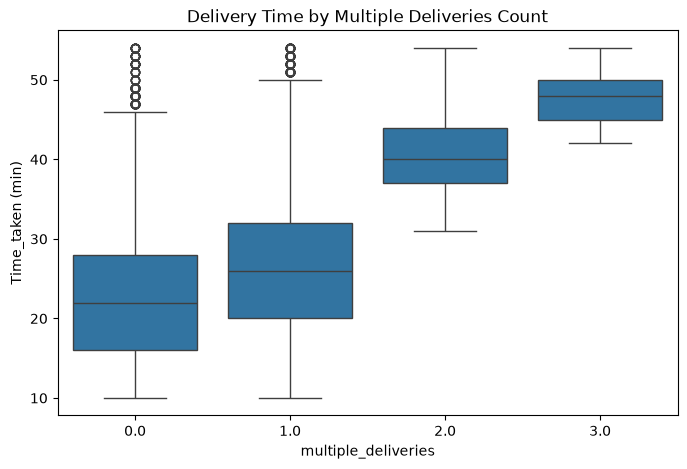

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='multiple_deliveries', y='Time_taken (min)')
plt.title('Delivery Time by Multiple Deliveries Count')
plt.show()

In [20]:
# as normally expected fewer itmes get delivered quicker as compared to multiple items

In [21]:
# now a final comparison betwen impact of feastival days on delivery times

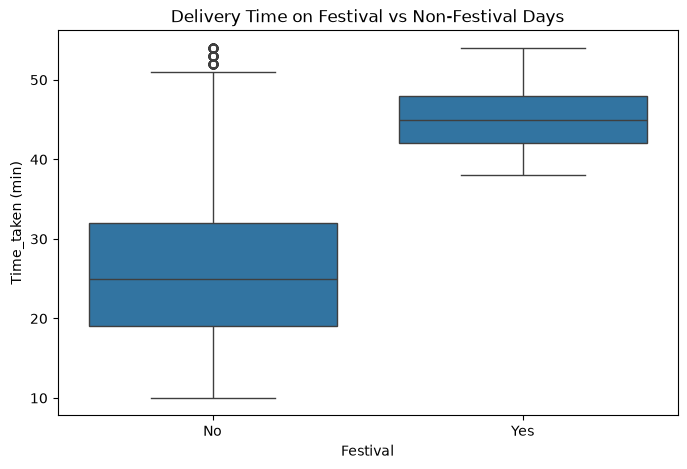

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Festival', y='Time_taken (min)')
plt.title('Delivery Time on Festival vs Non-Festival Days')
plt.show()

In [23]:
# again, the visualization vouches for the fact that delivery times were higher on feastival days 

In [24]:
# assuming distance would dominate, but operational factors — how many orders the rider was juggling, whether it was a festival day turned out to matter more

In [25]:
# in order to tackle the missing values in the age and ratings column we will just fill them with the median value
df_clean['Delivery_person_Ratings'] = df_clean['Delivery_person_Ratings'].fillna(df_clean['Delivery_person_Ratings'].median())
df_clean['Delivery_person_Age'] = df_clean['Delivery_person_Age'].fillna(df_clean['Delivery_person_Age'].median())

# delete the rows which dont have the time of ordering 
df_clean = df_clean.dropna(subset=['Time_Orderd'])

# city not being much significant gets filled with unknwown
df_clean['City'] = df_clean['City'].fillna('Unknown')

# filling the values with mode of the other entries (max occurence)
for col in ['multiple_deliveries', 'Weather_conditions', 'Road_traffic_density', 'Festival']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# check if there are still any values which may cause error (None or NA)
print(df_clean.isnull().sum().sort_values(ascending=False))
print(df_clean.shape)

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
distance_km                    0
dtype: int64
(40188, 21)


In [26]:
# 1. Ordinal: mapping the traffic type to a value, where in 3 denotes jam and 0 denotes low traffic
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
df_clean['Road_traffic_density'] = df_clean['Road_traffic_density'].map(traffic_map)

# 2. Binary: Festival 
df_clean['Festival'] = df_clean['Festival'].map({'Yes': 1, 'No': 0})

# 3. Nominal: one-hot encode Weather_conditions, Type_of_order, Type_of_vehicle, City
# Each row gets a 1 in exactly the column matching its actual value, 0 everywhere else

# There's no real ranking between weather types, they're just different, unrelated categories. This is the difference between ordinal data (has real order,
# like Low/Medium/High) and nominal data (no order, like weather types or vehicle types).
# One-hot encoding solves this by turning ONE column with multiple categories into SEVERAL new columns, one per category, each filled with 0 or 1.
df_clean = pd.get_dummies(df_clean, columns=['Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'City'], drop_first=True)

# note : the reason for droppin the first column is that we dont need all of them to be there is theres 0 in all of the other then definitely its the part of the dropped one, else you have itin the previous ccolumns

print(df_clean.shape)
df_clean.head()

(40188, 30)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weather_conditions_Sunny,Weather_conditions_Windy,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Semi-Urban,City_Unknown,City_Urban
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,False,False,False,False,True,True,False,False,False,False
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,False,False,False,True,False,True,False,False,False,False
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,False,False,True,False,False,False,True,False,False,False
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,False,False,False,False,False,True,False,False,False,False
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,False,False,False,False,True,False,True,False,False,False


In [28]:
# Dropping the columns which are of no use 
df_model = df_clean.drop(columns=[
    'ID', 'Delivery_person_ID',
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude',
    'Order_Date', 'Time_Orderd', 'Time_Order_picked'
])

print(df_model.shape)
df_model.dtypes

(40188, 21)


Delivery_person_Age              float64
Delivery_person_Ratings          float64
Road_traffic_density               int64
Vehicle_condition                  int64
multiple_deliveries              float64
Festival                           int64
Time_taken (min)                   int64
distance_km                      float64
Weather_conditions_Fog              bool
Weather_conditions_Sandstorms       bool
Weather_conditions_Stormy           bool
Weather_conditions_Sunny            bool
Weather_conditions_Windy            bool
Type_of_order_Drinks                bool
Type_of_order_Meal                  bool
Type_of_order_Snack                 bool
Type_of_vehicle_motorcycle          bool
Type_of_vehicle_scooter             bool
City_Semi-Urban                     bool
City_Unknown                        bool
City_Urban                          bool
dtype: object

In [ ]:
# importing sklearn for the model training 

from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Time_taken (min)'])
y = df_model['Time_taken (min)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

In [31]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.5857035162886888


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 3.137204901716845
Random Forest RMSE: 3.923263748104026
Random Forest R²: 0.8275188438360266


In [33]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

Delivery_person_Ratings          0.219068
distance_km                      0.148556
Road_traffic_density             0.140064
multiple_deliveries              0.107527
Delivery_person_Age              0.105769
Weather_conditions_Sunny         0.071700
Vehicle_condition                0.069019
Weather_conditions_Fog           0.033898
Weather_conditions_Sandstorms    0.020944
Weather_conditions_Windy         0.019911
Weather_conditions_Stormy        0.018483
Festival                         0.011586
City_Urban                       0.006718
Type_of_order_Meal               0.005803
Type_of_order_Snack              0.005520
Type_of_order_Drinks             0.005506
Type_of_vehicle_scooter          0.003161
Type_of_vehicle_motorcycle       0.002945
City_Semi-Urban                  0.002091
City_Unknown                     0.001732
dtype: float64


In [34]:
X_train_no_rating = X_train.drop(columns=['Delivery_person_Ratings'])
X_test_no_rating = X_test.drop(columns=['Delivery_person_Ratings'])

rf_model_v2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_v2.fit(X_train_no_rating, y_train)

y_pred_rf_v2 = rf_model_v2.predict(X_test_no_rating)

mae_v2 = mean_absolute_error(y_test, y_pred_rf_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_rf_v2))
r2_v2 = r2_score(y_test, y_pred_rf_v2)

print("Without Ratings — MAE:", mae_v2)
print("Without Ratings — RMSE:", rmse_v2)
print("Without Ratings — R²:", r2_v2)

Without Ratings — MAE: 3.4215333623621134
Without Ratings — RMSE: 4.273547451063716
Without Ratings — R²: 0.7953443659504876


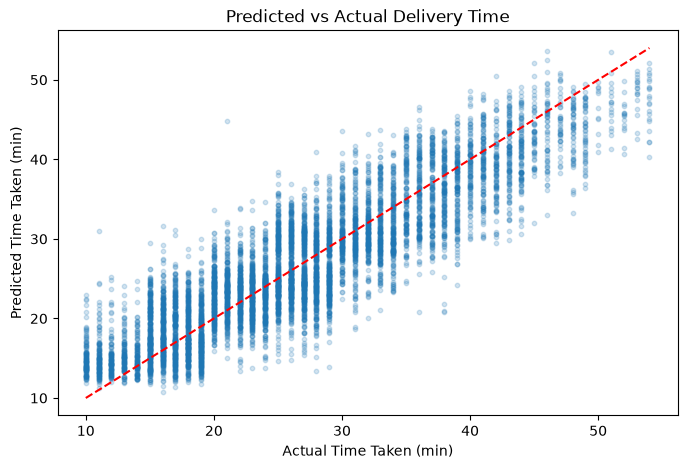

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf_v2, alpha=0.2, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual Time Taken (min)')
plt.ylabel('Predicted Time Taken (min)')
plt.title('Predicted vs Actual Delivery Time')
plt.show()

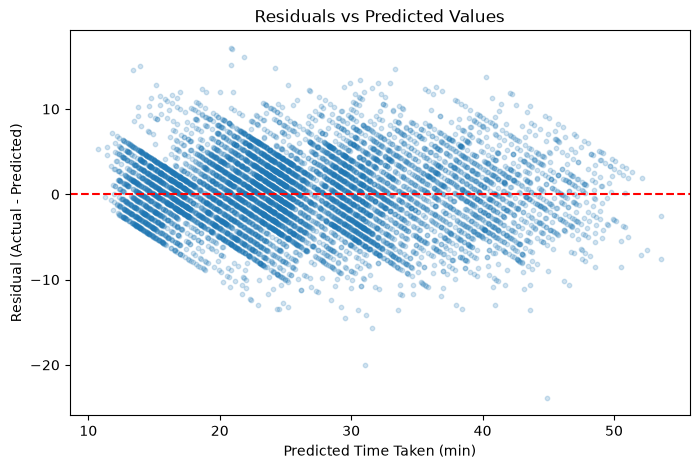

In [36]:
residuals = y_test - y_pred_rf_v2

plt.figure(figsize=(8,5))
plt.scatter(y_pred_rf_v2, residuals, alpha=0.2, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Time Taken (min)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.show()

In [37]:
model_final = LinearRegression()
model_final.fit(X_train_no_rating, y_train)

y_pred_final = model_final.predict(X_test_no_rating)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final Linear Regression — MAE:", mae_final)
print("Final Linear Regression — RMSE:", rmse_final)
print("Final Linear Regression — R²:", r2_final)

Final Linear Regression — MAE: 5.169240263133446
Final Linear Regression — RMSE: 6.477486724583641
Final Linear Regression — R²: 0.5298248116338713


In [38]:
import json

coefficients = dict(zip(X_train_no_rating.columns, model_final.coef_))
intercept = model_final.intercept_

print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in coefficients.items():
    print(f"  {feature}: {coef:.4f}")

Intercept: 9.935264082525219
Coefficients:
  Delivery_person_Age: 0.4259
  Road_traffic_density: 2.3587
  Vehicle_condition: -2.3109
  multiple_deliveries: 3.3029
  Festival: 10.0978
  distance_km: 0.3537
  Weather_conditions_Fog: 0.0429
  Weather_conditions_Sandstorms: -2.5043
  Weather_conditions_Stormy: -2.5074
  Weather_conditions_Sunny: -6.2087
  Weather_conditions_Windy: -2.3649
  Type_of_order_Drinks: 0.0631
  Type_of_order_Meal: 0.2050
  Type_of_order_Snack: 0.1236
  Type_of_vehicle_motorcycle: -0.5097
  Type_of_vehicle_scooter: -0.9562
  City_Semi-Urban: 10.6487
  City_Unknown: -2.6601
  City_Urban: -2.2421


In [40]:
print(df_model['City_Semi-Urban'].sum())

141


In [41]:
export_data = {
    "intercept": float(intercept),
    "coefficients": {k: float(v) for k, v in coefficients.items()}
}

with open("model_export.json", "w") as f:
    json.dump(export_data, f, indent=2)

print("Saved!")

Saved!
